
1. Using pandas, import csv of the countries data.

In [1]:

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Datasets_50_Days_Of_Data_Analysis/countries_population_data.csv")
df.head()

,Country,Population,GDP_per_capita,Unemployment_rate,Area
0,United States,331002651,65298,6.10%,9629091
1,China,1439323776,16708,3.80%,9640011
2,Japan,126476461,39058,2.80%,377975
3,Germany,83783942,55803,3.20%,357022
4,United Kingdom,67886011,44177,4.80%,242500



2. You have decided to add another column to your DataFrame. The column will have capital cities of each country. Here is the data below:

In [2]:
df_copy = df.copy()

In [7]:

# Reading capital cities data
df2 = pd.read_csv("Datasets_50_Days_Of_Data_Analysis/Countries_data_capital_cities.csv")
df2.head()

,Country,Capital_City
0,United States,"Washington, D.C."
1,China,Beijing
2,Japan,Tokyo
3,Germany,Berlin
4,United Kingdom,London


In [8]:
# Using merge to merge DataFrame on 'Country'
merged_df = df_copy.merge(df2, on='Country')
merged_df.head()

,Country,Population,GDP_per_capita,Unemployment_rate,Area,Capital_City
0,United States,331002651,65298,6.10%,9629091,"Washington, D.C."
1,China,1439323776,16708,3.80%,9640011,Beijing
2,Japan,126476461,39058,2.80%,377975,Tokyo
3,Germany,83783942,55803,3.20%,357022,Berlin
4,United Kingdom,67886011,44177,4.80%,242500,London



3. Using Matplotlib, create a bar chart to visualize the distribution of population among different continents.

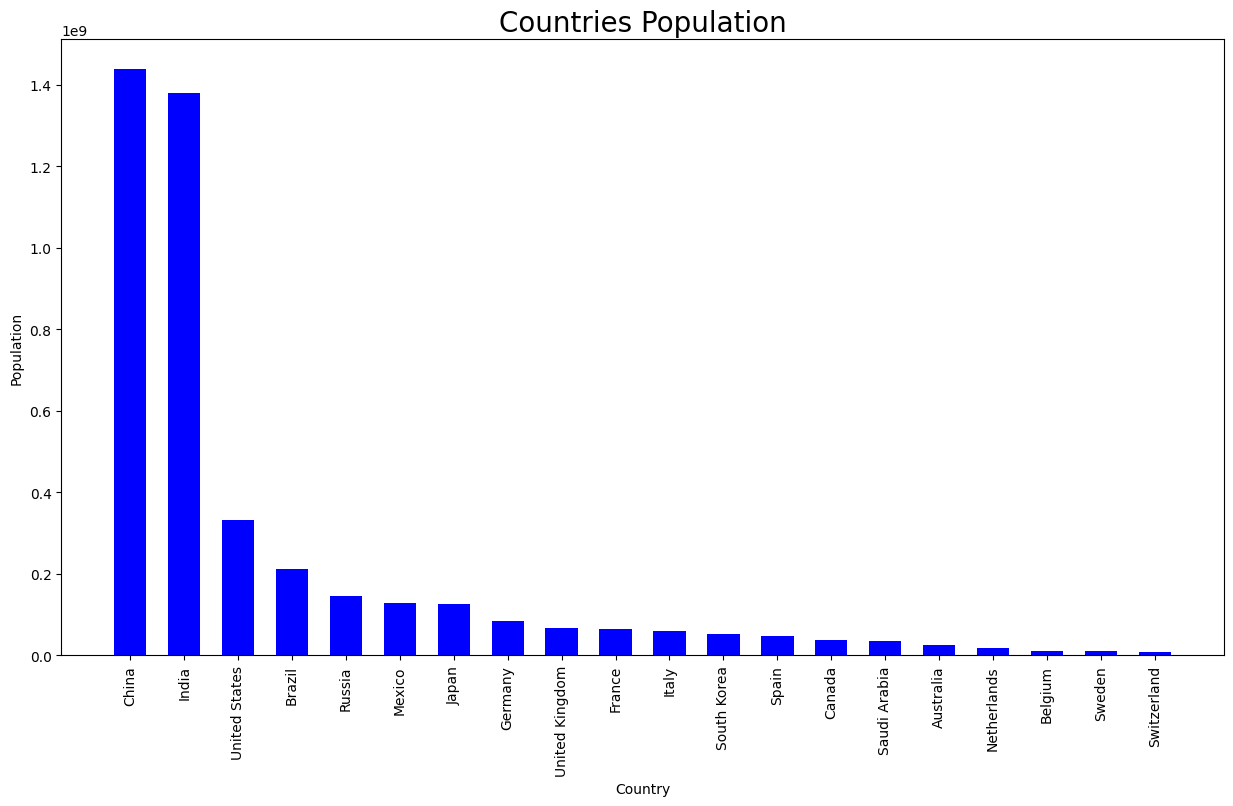

In [9]:

import matplotlib.pyplot as plt

merged_df.sort_values(by = ["Population"], axis=0, 
                      inplace=True, 
                      ascending=False)    
fig = plt.figure(figsize = (15, 8))
plt.bar(merged_df.Country, merged_df.Population,
        color ='blue',
        width = 0.6)
 
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation = 90)
plt.title("Countries Population", fontsize = 20)
plt.show()


4. Using NumPy, calculate the correlation between the population and GDP per capita for each country and create a scatter plot to visualize the relationship between the two variables (population and GDP per capita) using matplotlib.

In [10]:
import numpy as np

population = merged_df["Population"]
gdp_per_capita = merged_df["GDP_per_capita"]
correlation = np.corrcoef(population, gdp_per_capita)
correlation

array([[ 1.        , -0.49159759],
       [-0.49159759,  1.        ]])

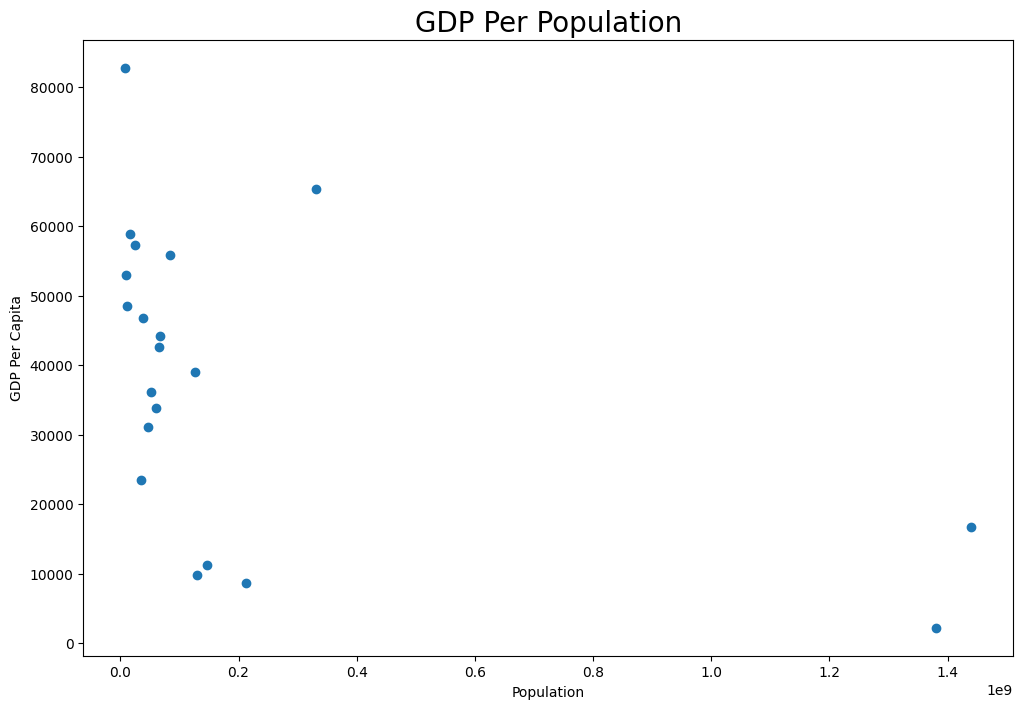

In [11]:

import matplotlib.pyplot as plt

fig = plt.figure(figsize = (12, 8))
plt.scatter(population, gdp_per_capita)
plt.xlabel('Population')
plt.ylabel('GDP Per Capita')
plt.title("GDP Per Population", fontsize= 20)
plt.show()



5. Using pandas return the top 3 countries with the lowest GDP. Assign this to a variable.

In [12]:

df_low_gdp_3 = merged_df.sort_values(by='GDP_per_capita', ascending=True, 
                                     inplace=False).head(3)
df_low_gdp_3

,Country,Population,GDP_per_capita,Unemployment_rate,Area,Capital_City
16,India,1380004385,2252,6.10%,3287263,New Delhi
17,Brazil,212559417,8711,13.90%,8515767,Brasília
10,Mexico,128932753,9877,3.60%,1964375,Mexico City



6. Compare the unemployment rate of Switzerland, China and USA. Plot that on a bar plot.

In [ ]:
countries = ["Switzerland", "China", "United States"]

filtered_df = merged_df.query("Country==@countries" )
filtered_df

,Country,Population,GDP_per_capita,Unemployment_rate,Area,Capital_City
1,China,1439323776,16708,3.80%,9640011,Beijing
0,United States,331002651,65298,6.10%,9629091,"Washington, D.C."
13,Switzerland,8654622,82792,2.50%,41285,Bern


In [14]:
filtered_df["Unemployment_rate"] = filtered_df["Unemployment_rate"].str.replace("%", "").astype(float)
filtered_df

,Country,Population,GDP_per_capita,Unemployment_rate,Area,Capital_City
1,China,1439323776,16708,3.8,9640011,Beijing
0,United States,331002651,65298,6.1,9629091,"Washington, D.C."
13,Switzerland,8654622,82792,2.5,41285,Bern


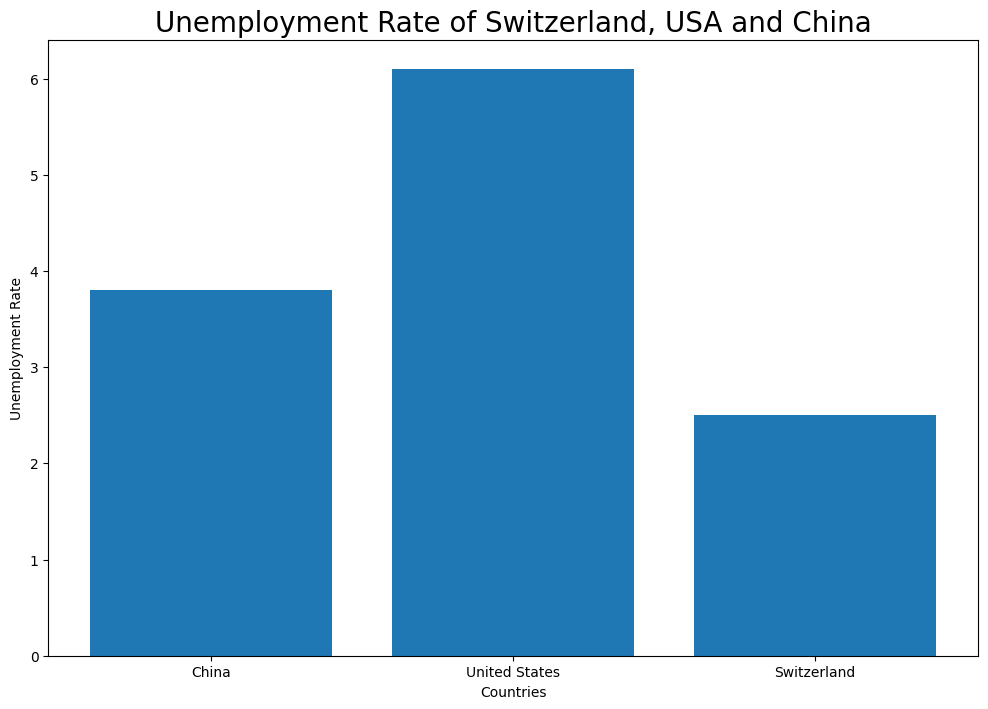

In [15]:

plt.figure(figsize=(12, 8))
plt.bar(filtered_df.Country, filtered_df.Unemployment_rate)
plt.xlabel("Countries")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate of Switzerland, USA and China",fontsize=20)
plt.show()